In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(x_train)

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [7]:
model = models.Sequential([
    layers.UpSampling2D(size=(3,3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 405s 255ms/step - accuracy: 0.5590 - loss: 1.2747 - val_accuracy: 0.7015 - val_loss: 0.8832
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 236ms/step - accuracy: 0.6318 - loss: 1.0719 - val_accuracy: 0.7303 - val_loss: 0.7938
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 395s 253ms/step - accuracy: 0.6475 - loss: 1.0237 - val_accuracy: 0.7370 - val_loss: 0.7687
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 391s 250ms/step - accuracy: 0.6587 - loss: 0.9993 - val_accuracy: 0.7268 - val_loss: 0.7935
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 392s 251ms/step - accuracy: 0.6640 - loss: 0.9759 - val_accuracy: 0.7349 - val_loss: 0.7896
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 384s 246ms/step - accuracy: 0.6722 - loss: 0.9544 - val_accuracy: 0.7453 - val_loss: 0.7474
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7440s 5s/step - accuracy: 0.6758 - loss: 0.9467 - val_accuracy: 0.7485 - val_loss: 0.7443
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 376s 241ms/step - accu

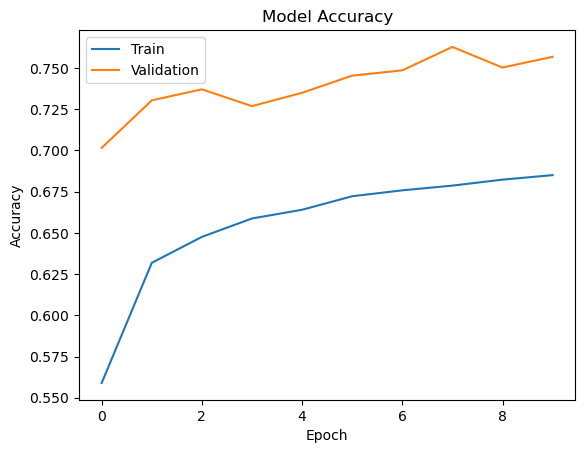

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

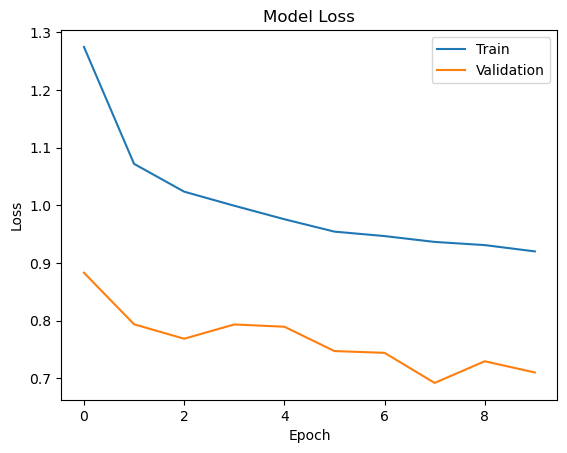

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 218ms/step - accuracy: 0.7567 - loss: 0.7102
Test Accuracy: 0.7566999793052673


In [13]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 222ms/step
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1000
           1       0.79      0.94      0.86      1000
           2       0.74      0.67      0.70      1000
           3       0.68      0.50      0.58      1000
           4       0.77      0.66      0.71      1000
           5       0.75      0.64      0.69      1000
           6       0.61      0.90      0.73      1000
           7       0.74      0.83      0.79      1000
           8       0.92      0.81      0.86      1000
           9       0.84      0.80      0.82      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.75     10000
weighted avg       0.76      0.76      0.75     10000



In [14]:
model.save("saved_model/my_model.h5")

In [16]:
model.save("saved_model/my_model.keras")